# 변수 선택

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 데이터 병합
- 분석의 규모가 커지게 되면 여러개의 데이터 테이블을 이용
    - 하나의 테이블에 모든 데이터를 기록하는 것은 좋지 않기 때문
- 데이터분석을 위해서는 여러개로 분할된 데이터 테이블을 하나로 만들어서 분석하는 것이 중요함
- Pandas의 경우 DataFrame과 DataFrame을 연결 또는 병합할 수 있음
    - `concat()` : 단순히 DataFrame을 연결(인덱스기준)
    - `merge()` : 특정한 기준으로 DataFrame을 연결(열의 값 기준)

### `pandas.concat()`
- 단순히 DataFrame을 연결하는 것으로 인덱스값이 중복될 수 있음

```
pandas.concat([dataframe,...dataframe], axis, join, ignore_index)
```
- `axis`
    - 상하연결(axis=0)
    - 좌우연결(axis=1)
- `join`
    - 동일한 이름을 가지는 인덱스가 없는 NaN값으로 대체(join='outer')(기본값)
    - 동일한 이름을 가지는 인덱스만 연결(join='inner')
- `ignore_index`
    - 기존의 인덱스를 무시하고 연결(ignore=True)



In [4]:
df1 = pd.DataFrame({
    'K' : ['K0', 'K1', 'K2'],
    'X1': ['A', 'B', 'C'],
    'X2': [1, 2, 3]
})
df1

,K,X1,X2
0,K0,A,1
1,K1,B,2
2,K2,C,3


In [5]:
df2 = pd.DataFrame({
    'K' : ['K1', 'K2', 'K3'],
    'X2': ['B', 'A', 'D'],
    'X3': [4, 5, 6]
})
df2

,K,X2,X3
0,K1,B,4
1,K2,A,5
2,K3,D,6


In [6]:
# 위아래로 합치기
pd.concat([df1,df2],axis=0)

,K,X1,X2,X3
0,K0,A,1,NaN
1,K1,B,2,NaN
2,K2,C,3,NaN
0,K1,NaN,B,4.0
1,K2,NaN,A,5.0
2,K3,NaN,D,6.0


In [ ]:
# 동일한 컬럼만 위아래로 합치기
pd.concat([df1,df2],axis=0, join='inner')

In [ ]:
# 좌우로 합치기
pd.concat([df1,df2],axis=1)

In [7]:
# 인덱스를 무시하고 좌우로 합치기
pd.concat([df1,df2],axis=1, ignore_index=True)

,0,1,2,3,4,5
0,K0,A,1,K1,B,4
1,K1,B,2,K2,A,5
2,K2,C,3,K3,D,6


### `pandas.merge()`
- 두 DataFrame의 공통 열 혹은 인덱스를 기준으로 두 DataFrame을 병합

```
pandas.merge(dataframe, dataframe, on, how)
```
- `on`
    - 기준이 되는 열, 행의 데이터를 키(Key)라고 하며, 병합기준이 될 컬럼을 on으로 설정
    - 컬럼명이 다를 경우, `left_on`과 `right_on`으로 기준이 되는 컬럼명 지정
- `how` : 결합 방법
    - `inner` : 키가 중복되어 존재하는 경우만 결합
    - `outer` : 동일한 키가 없는 경우 NaN으로 대체하여 결합
    - `left` : 왼쪽 DataFrame의 키를 기준으로 결합
    - `right` : 오른쪽 DataFrame의 키를 기준으로 결합



In [9]:
# K열의 값이 공통이 되는 행만 결합
pd.merge(df1,df2, on ='K', how='inner')

,K,X1,X2_x,X2_y,X3
0,K1,B,2,B,4
1,K2,C,3,A,5


In [10]:
# K열의 값이 공통이 되지 않는 값을 NaN로 결합
pd.merge(df1,df2, on ='K', how='outer')

,K,X1,X2_x,X2_y,X3
0,K0,A,1.0,NaN,NaN
1,K1,B,2.0,B,4.0
2,K2,C,3.0,A,5.0
3,K3,NaN,NaN,D,6.0


In [11]:
# 왼쪽 데이터프레임(df1)으로 K열의 값을 결합
pd.merge(df1,df2, on ='K', how='left')

,K,X1,X2_x,X2_y,X3
0,K0,A,1,NaN,NaN
1,K1,B,2,B,4.0
2,K2,C,3,A,5.0


In [12]:
# 오른쪽 데이터프레임(df2)으로 K열의 값을 결합
pd.merge(df1,df2, on ='K', how='right')

,K,X1,X2_x,X2_y,X3
0,K1,B,2.0,B,4
1,K2,C,3.0,A,5
2,K3,NaN,NaN,D,6


## 변수간의 상관관계
- 독립변수들 선형관계가 존재하는 경우 해당 변수를 중복하여 반영되거나 다중공선성 (multicolinearity) 발생
- 다중공선성의 영향
    - 회귀계수 추정량의 변동성이 커져, 개별 독립변수의 유의성 검정(t-검정)에서 pvalue가 커지는 경향이 있음
    - 중복효과 존재로 인해 서로 연관된 독립변수 중 일부를 모형에서 추가하거나 제거했을 때, 해당 변수의 계수 추정값이 크게 변하거나 부호가 바뀔 수도 있음
    - 종속변수의 추정에는 일반적으로 큰 영향을 미치지 않아 모형의 전반적인 유의성 검정에서 작게 도출된 p-value가 t-검정의 p-value와 해석이 상충하게 됨
- 독립변수들간의 상관관계를 분석하여 데이터 전처리 필요

### 상관분석
- 두 변수 간의 관계를 측정하는 통계적 기법
    - 공분산(Covariance) : 두 개의 확률변수  X,Y 에 관한 선형적 연관성을 나타내는 특성값 <br>
    $COV[X,Y] = \sigma_{XY} = E[(X- \mu_X)(Y - \mu_Y)] = E[XY] - \mu_X\mu_Y$
    - 상관계수(Correlation coefficient) : 두 개의 확률변수  X,Y 의 선형적 연관성의 방향과 강도를 동시에 파악할 뿐 아니라 자료의 단위에도 의존하지 않도록 공분산을 보정한 지표 <br>
    $CORR[X,Y] = \rho_XY = \frac{COV[X,Y]}{S[X]S[Y]}$
- 공분산 행렬(Covariance Matrix)
    - 각 변수의 변동이 얼마나 닮았는지 비교
    - 모든 변수에 대하여 분산과 공분산 값을 나타내는 정사각 행렬
    - 주 대각선 성분은 자기 자신의 분산 값
    - 주 대각선 이외의 성분은 가능한 두 변수의 공분산 값 <br>
$\begin{bmatrix}
    var(x) & cov(x,y) \newline cov(x,y) & var(y)
\end{bmatrix}$
```
df.cov()
np.cov()
```
- 상관계수(Correlation Coefficient)
    - 공분산을 두 변수의 표준편차로 나누어준 값
    - 공분산의 스케일을 조정하여 어떠한 선형관계에 있는지 확인
    ```
    df.corr()
    np.corrcoef()
    ```

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
# 데이터 불러오기
taxis = pd.read_csv('/content/drive/MyDrive/taxis/df_taxis.csv')
taxis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6329 entries, 0 to 6328
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pickup                 6329 non-null   object 
 1   dropoff                6329 non-null   object 
 2   passengers             6329 non-null   int64  
 3   distance               6329 non-null   float64
 4   fare                   6329 non-null   float64
 5   tip                    6329 non-null   float64
 6   tolls                  6329 non-null   float64
 7   total                  6329 non-null   float64
 8   color                  6329 non-null   object 
 9   payment                6329 non-null   object 
 10  pickup_zone            6329 non-null   object 
 11  dropoff_zone           6329 non-null   object 
 12  pickup_borough         6329 non-null   object 
 13  dropoff_borough        6329 non-null   object 
 14  ride_hour              6329 non-null   float64
 15  dist

In [15]:
# 수치형 컬럼만 선택
taxis_numeric = taxis.select_dtypes(include='number')
# distance는 제외
taxis_numeric.drop(columns=['distance'], inplace=True)
# 변수간의 상관관계 파악
corr_taxis = taxis_numeric.corr()
corr_taxis

,passengers,fare,tip,tolls,total,ride_hour,distance_root
passengers,1.000000,0.006648,0.016923,-0.003471,0.013954,-0.004819,0.009868
fare,0.006648,1.000000,0.470322,0.611016,0.973749,-0.010889,0.933006
tip,0.016923,0.470322,1.000000,0.405029,0.632332,0.027477,0.476599
tolls,-0.003471,0.611016,0.405029,1.000000,0.685149,0.011652,0.582225
total,0.013954,0.973749,0.632332,0.685149,1.000000,0.010020,0.915668
ride_hour,-0.004819,-0.010889,0.027477,0.011652,0.010020,1.000000,-0.022788
distance_root,0.009868,0.933006,0.476599,0.582225,0.915668,-0.022788,1.000000


<Axes: >

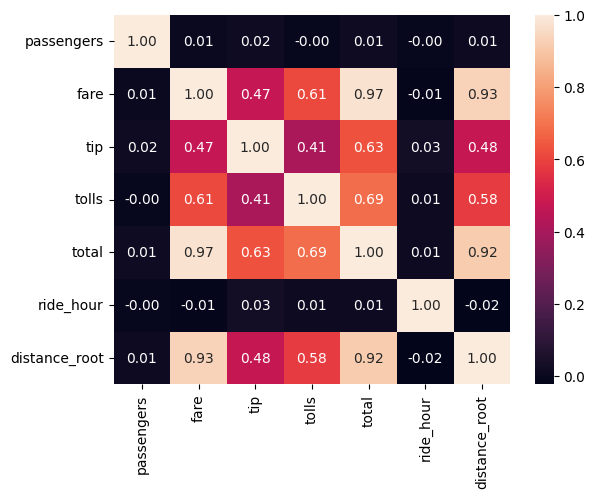

In [16]:
# 상관계수 히트맵 그리기
sns.heatmap(corr_taxis, annot=True, fmt='.2f')

In [17]:
# 공분산
cov_taxis = taxis_numeric.cov()
cov_taxis

,passengers,fare,tip,tolls,total,ride_hour,distance_root
passengers,1.461586,0.090690,0.048711,-0.005887,0.227120,-0.035001,0.009844
fare,0.090690,127.331256,12.635586,9.671478,147.931269,-0.738155,8.686946
tip,0.048711,12.635586,5.668452,1.352667,20.268551,0.393003,0.936269
tolls,-0.005887,9.671478,1.352667,1.967636,12.939057,0.098189,0.673874
total,0.227120,147.931269,20.268551,12.939057,181.255334,0.810409,10.171816
ride_hour,-0.035001,-0.738155,0.393003,0.098189,0.810409,36.089692,-0.112955
distance_root,0.009844,8.686946,0.936269,0.673874,10.171816,-0.112955,0.680817


### 차원 축소 (Reduction)
- 분석 결과의 신뢰성, 성능을 위해 필요한 변수의 효율적 선택이 필요
    - 변수들에 대한 중요도를 기준으로 변수를 선택 (전진선택법, 후진선택법, 단계적선택법)
- 차원 축소 방법
    - 요인분석 : 두개 이상의 변수간의 상관관계를 가질 때 이러한 변수들의 특징 파악하여 공통차원으로 축약
        - 주성분 분석 : 분포된 데이터들의 특성을 설명할 수 있는 하나 또는 복수 개의 특징(주성분)을 찾는 분석 방법
    - 새로운 변수 생성 : 분석 목표에 적합한 변수를 생성하는 방법
        - 요약변수 : 수집된 정보를 분석에 맞게 종합/요약(aggregate)한 변수(단순 종합 개념)
            - 예 : 시험 범수의 평균, 기간별 평균 구매금액
        - 파생변수 : 특정 조건을 만족하거나 특정 함수에 의해 생성된 변수(주관적 변수)
            - 예 : 키와 몸무게에 대한 BMI (체질량지수), 주요 구매 상품
            - 변수간의 상호작용으로 종속변수에 영향을 미치는 경우, 이를 반영한 파생변수 생성

https://youtu.be/C21GoH0Y9AE?si=OcknhLDYhQyFeDNV

### 주성분 분석 (PCA, Principal Component Analysis)
- 여러 변수들의 변량을 주성분이라고 불리는 서로 상관성이 높은 여러 변수들의 선형 조합으로 만든 새로운 변수들로 요약/축소하는 기법
- 서로 연관 가능성이 있는 고차원 공간의 표본들을 선형 연관성이 없는 저차원 공간의 표본으로 변환하여 새로운 변수들로 요약/축소하는 기법
- 분산을 최대로 보존할 수 있는 축을 선택하는 것이 정보를 가장 적게 손실할 수 있음 (큰 분산은 해당 방향에 데이터의 주요 정보나 패턴이 포함되어 있음)
- 데이터를 한개의 축으로 투영시켰을 때 그 분산이 가장 커지는 축을 첫 번째 주성분, 두 번째로 커지는 축을 두 번째 주성분으로 놓이도록 새로운 좌표계로 데이터를 선형 변환하는 방식으로 동작됨(두번재 성분은 첫번째 성분의 직교방향 벡터)

    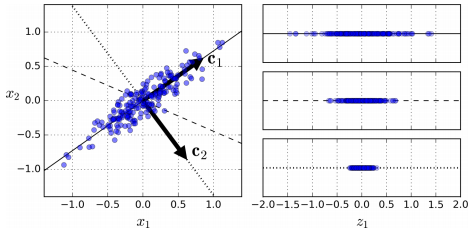

- 고유값(eigenvalue), 고유벡터(eigenvector)
    - 고유벡터(v) : 행렬 A를 선형변환으로 봤을 때, 선형변환 A에 의한 변환 결과가 자기자신의 상수배가 되는 0이 아닌 벡터
        - 공분산 행렬의 고유벡터 : 데이터가 어떤 방향으로 분산되어 있는지 확인
    - 고유값(λ): 상수배 값 <br>
        - 고유벡터 방향으로 얼마만큼의 크기로 벡터 공산이 늘려지는지를 의미
        - 고유값이 큰 순서대로 고유벡터를 정렬하면 결과적으로 중요한 순서대로 주성분을 구성하게 됨
$Av = λv$ <br>
$
\begin{pmatrix}
a_{11} & \cdots & a_{1n} \\
\vdots & \ddots & \vdots \\
a_{n1} & \cdots & a_{nn}
\end{pmatrix}\begin{pmatrix}
v_{1}\\
\vdots\\
v_{n}
\end{pmatrix} = \lambda\begin{pmatrix}
v_{1}\\
\vdots\\
v_{n}
\end{pmatrix}$


In [ ]:
#두개의 특성(분산 비율) 을 모두 반영한 새로운 변수를 만들어준다
#하나의 선으로 만들어주는 것이 더 데이터의 특징을 많이 반영한다.
#그 때 선으로 옮기는 축이 가장 적게 옮기게 되는 축으로..
#분산의 비율을 가장 많이 반영한 예를 들어 95%기준으로 해줄 수 있고

In [18]:
from sklearn.decomposition import PCA

# 1. 데이터 생성
X = np.array([[2.5, 2.4], [0.5, 0.7], [2.2, 2.9], [1.9, 2.2], [3.1, 3.0], [2.3, 2.7]])
df_X = pd.DataFrame(X, columns=['x1', 'x2'])

# 2. 데이터 표준화
X_mean = df_X.mean()
X_centered = df_X - X_mean

# 3. 공분산 행렬 계산
cov_matrix = np.cov(X_centered.T)
print(cov_matrix)

# 4. 고유값과 고유벡터 계산
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) # 선형변환

# 5. 주성분 정렬
idx = np.argsort(eigenvalues)[::-1] # 제일 큰 값 가져옴
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 결과 출력
print("고유값:", eigenvalues)
print("고유벡터 (주성분):", eigenvectors)

# Sklearn을 사용한 PCA
pca = PCA(n_components=2) # 줄일 수 있는 component 2로 설정
X_pca = pca.fit_transform(X)
print("Sklearn PCA 결과:", X_pca) #원본 데이터를 새로운 축(주성분 축)으로 변환한 값
print("첫번째 주성분 벡터:", pca.components_.T[:,0])

# 설명된 분산의 비율
print("설명된 분산의 비율:", pca.explained_variance_ratio_)

[[0.76166667 0.69233333]
 [0.69233333 0.71766667]]
고유값: [1.43234945 0.04698388]
고유벡터 (주성분): [[ 0.71824807 -0.69578712]
 [ 0.69578712  0.71824807]]
Sklearn PCA 결과: [[ 0.35725229 -0.23005729]
 [-2.26208195 -0.05950477]
 [ 0.48967143  0.33780287]
 [-0.21285398  0.04376536]
 [ 1.2056734  -0.21658073]
 [ 0.42233881  0.12457455]]
첫번째 주성분 벡터: [0.71824807 0.69578712]
설명된 분산의 비율: [0.96823983 0.03176017]


In [19]:
# 적절한 차원 수 선택하기 (설명된 분산의 비율 95% 이상의 차원수 선택)
# 방법 1
pca = PCA()
pca.fit(df_X)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum <= 0.95) + 1
print("분산비율 95%를 유지하기 위한 최소의 차원수 :", d)

# 방법 2
pca = PCA(n_components=0.95) #총 분산의 95%를 설명하는 주성분 개수를 계산하여 PCA분석 수행
x_reduced = pca.fit_transform(df_X)
print("분산의 95%를 설명하는 최소의 차원수를 기준으로 PCA결과 : ", x_reduced)

분산비율 95%를 유지하기 위한 최소의 차원수 : 1
분산의 95%를 설명하는 최소의 차원수를 기준으로 PCA결과 :  [[ 0.35725229]
 [-2.26208195]
 [ 0.48967143]
 [-0.21285398]
 [ 1.2056734 ]
 [ 0.42233881]]


In [20]:
# 변환된 데이터를 새로운 차원(파생변수로 지정)
# 새로운 데이터를 데이터프레임으로 변환
df_pca = pd.DataFrame(x_reduced, columns=['PCA1'])
# 기존데이터프레임과 병합
result_df = pd.concat([df_X, df_pca], axis=1)
result_df.head()

,x1,x2,PCA1
0,2.5,2.4,0.357252
1,0.5,0.7,-2.262082
2,2.2,2.9,0.489671
3,1.9,2.2,-0.212854
4,3.1,3.0,1.205673


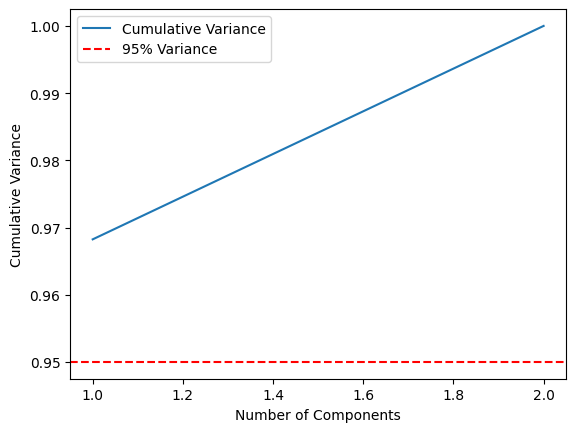

In [21]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(cumsum) + 1), cumsum, label='Cumulative Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.show()

#우리가 95만 넘으면 된다고 볼 때 1에서 0.95가 넘으니 1차원으로 축소 가능

In [25]:
# 상관관계가 높은 distance와 fare 컬럼 선택
selected_df = taxis.loc[:,['distance_root', 'fare']]
# 주성분 분석을 통해 차원 축소
pca = PCA(n_components = 0.95) # 위 두개의 컬럼의 값이 95프로로 반영되는 pca값
selected_pca = pca.fit_transform(selected_df)
selected_pca.shape # 1차원인것 확인

(6329, 1)

In [26]:
# 데이터프레임의 축소된 차원(공통요인) 추가
df_pca = pd.DataFrame(selected_pca, columns = ['dis*fare'])
result_df = pd.concat([taxis,df_pca], axis = 1)
result_df.head()
# PCA의 결과(공통요인을 추가한 값 (얼마나 그 선과 떨어져있는지가 나오는 것임))은 의미가 없다
# 한개의 차원일 떄는 특히 값에 의미가 없다고 볼 수 있다.
# 두개의 차원일 때는 (-151, 50)으로 나온다면 주성분 1과 2의 반영값이 절댓값으로 151, 50으로 달라지기 때문에 의미를 부여할 수 있다.
# 데이터 분석 시에는 PCA의 결과에대한 상관관계가 더 중요한다고 볼 수 있다.
# ㄴ (PCA한 결과가 상관관계가 더 높은지 낮은지에대한 판단)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,...,dropoff_zone,pickup_borough,dropoff_borough,ride_hour,distance_root,ride_hour_category_새벽,ride_hour_category_오전,ride_hour_category_오후,ride_hour_category_저녁,dis*fare
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,...,UN/Turtle Bay South,Manhattan,Manhattan,20.0,1.264911,False,False,False,True,-6.045198
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,...,Upper West Side South,Manhattan,Manhattan,16.0,0.888819,False,False,True,False,-8.066170
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,...,West Village,Manhattan,Manhattan,17.5,1.170470,False,False,True,False,-5.552792
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,...,Yorkville West,Manhattan,Manhattan,1.0,2.774887,True,False,False,False,14.011203
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,...,Yorkville West,Manhattan,Manhattan,13.0,1.469694,False,False,True,False,-4.035895


#### [실습] 정제된 데이터에 대하여 각 변수간의 관계를 파악하고 이에 전처리
- [품목 가격정보 > 배추](https://drive.google.com/file/d/1bWUD_ViVPpAl_1j3OHUHzKwOsrlGqAep/view?usp=sharing)
- [서울시 기온](https://drive.google.com/file/d/1kHgK36HgH3oGw0fVOccrjATaX0S8tTkW/view?usp=sharing)
- [서울시 강수량](https://drive.google.com/file/d/1amvnRXiWRCbsNAPtcdcnWg1scdZgDrWS/view?usp=sharing)
- [소비자물가지수](https://drive.google.com/file/d/1mDDq5_dUGkx-DSfpRnO8fXh5QtIHd7xO/view?usp=sharing)
- [수출입동향](https://drive.google.com/file/d/1rVDnF12M7_pX4wXHIt1v2B6toL4Senn3/view?usp=sharing)
1. 수출입동향 데이터를 제외한 4개의 데이터 병합
2. 병합된 데이터에 대하여 기온/강수량/물가지수간의 상관관계 분석
3. 상관관계가 있다면 차원 축소
4. 가격과 기온/강수량/물가지수간의 상관관계 분석

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
df_price = pd.read_csv('/content/drive/MyDrive/taxis/df_price.csv')
df_price.head()

,구분,Year,Value,date
0,01월,2024년,3043,2024-01-01
1,02월,2024년,3457,2024-02-01
2,03월,2024년,3673,2024-03-01
3,04월,2024년,4402,2024-04-01
4,05월,2024년,3814,2024-05-01


In [25]:
df_degree = pd.read_csv('/content/drive/MyDrive/taxis/df_degree.csv')
df_degree.head()

,\t\t지점번호,지점명,일시,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자
0,108,서울,2020-01-01,1.6,5.9,11.9,2020-01-26,-1.7,-6.5,2020-01-01
1,108,서울,2020-02-01,2.5,7.2,15.6,2020-02-15,-1.3,-11.8,2020-02-06
2,108,서울,2020-03-01,7.7,13.3,20.6,2020-03-26,2.6,-2.8,2020-03-05
3,108,서울,2020-04-01,11.1,16.6,23.8,2020-04-16,6.3,1.9,2020-04-05
4,108,서울,2020-05-01,18.0,23.3,30.0,2020-05-30,13.7,9.2,2020-05-20


In [26]:
# 테이블을 병합하기 위하여 바꿔줌
df_degree = df_degree.rename(columns = {'일시':'date'})
df_degree.head(1)

,\t\t지점번호,지점명,date,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자
0,108,서울,2020-01-01,1.6,5.9,11.9,2020-01-26,-1.7,-6.5,2020-01-01


In [27]:
df_rain = pd.read_csv('/content/drive/MyDrive/taxis/df_rain.csv')
df_rain.head()

,년월,지점,강수량(mm)
0,2020-01-01,108,60.5
1,2020-02-01,108,53.1
2,2020-03-01,108,16.3
3,2020-04-01,108,16.9
4,2020-05-01,108,112.4


In [28]:
df_rain = df_rain.rename(columns = {'년월':'date'})
df_rain.head(1)

,date,지점,강수량(mm)
0,2020-01-01,108,60.5


In [29]:
df_index = pd.read_csv('/content/drive/MyDrive/taxis/df_index.csv')
df_index.head()

,시점,소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
0,2020-01-01,106.09,115.77,102.89,88.98,106.32,102.20,111.26
1,2020-02-01,106.06,114.81,103.09,88.98,106.40,102.05,111.21
2,2020-03-01,105.97,115.96,102.59,88.98,106.50,101.85,111.18
3,2020-04-01,105.55,116.78,101.54,88.98,106.58,100.70,111.20
4,2020-05-01,105.32,114.88,101.41,88.98,106.74,100.57,110.92


In [30]:
df_index = df_index.rename(columns={'시점':'date'})
df_index.head(1)

,date,소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
0,2020-01-01,106.09,115.77,102.89,88.98,106.32,102.2,111.26


In [10]:
# df_price(가격) , df_degree(기온), df_rain(강수량), df_index(소비자물가지수)

In [31]:
merge_one = pd.merge(df_price, df_degree, on = 'date', how = 'inner')
merge_one.head(1)

,구분,Year,Value,date,\t\t지점번호,지점명,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자
0,01월,2024년,3043,2024-01-01,108,서울,-0.5,3.6,10.6,2024-01-31,-3.9,-14.0,2024-01-23


In [32]:
merge_two = pd.merge(merge_one, df_rain, on = 'date', how = 'inner')
merge_two.head(1)

,구분,Year,Value,date,\t\t지점번호,지점명,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자,지점,강수량(mm)
0,01월,2024년,3043,2024-01-01,108,서울,-0.5,3.6,10.6,2024-01-31,-3.9,-14.0,2024-01-23,108,18.9


In [33]:
merge_final = pd.merge(merge_two, df_index, on = 'date', how='inner')
merge_final = merge_final.sort_values(by='date')
merge_final = merge_final.drop(columns=['\t\t지점번호'])
merge_final.head()

,구분,Year,Value,date,지점명,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),...,최저기온일자,지점,강수량(mm),소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
48,01월,2020년,4608,2020-01-01,서울,1.6,5.9,11.9,2020-01-26,-1.7,...,2020-01-01,108,60.5,106.09,115.77,102.89,88.98,106.32,102.20,111.26
49,02월,2020년,4366,2020-02-01,서울,2.5,7.2,15.6,2020-02-15,-1.3,...,2020-02-06,108,53.1,106.06,114.81,103.09,88.98,106.40,102.05,111.21
50,03월,2020년,4343,2020-03-01,서울,7.7,13.3,20.6,2020-03-26,2.6,...,2020-03-05,108,16.3,105.97,115.96,102.59,88.98,106.50,101.85,111.18
51,04월,2020년,4508,2020-04-01,서울,11.1,16.6,23.8,2020-04-16,6.3,...,2020-04-05,108,16.9,105.55,116.78,101.54,88.98,106.58,100.70,111.20
52,05월,2020년,4793,2020-05-01,서울,18.0,23.3,30.0,2020-05-30,13.7,...,2020-05-20,108,112.4,105.32,114.88,101.41,88.98,106.74,100.57,110.92


In [34]:
# 수치형 컬럼 선택
merge_final_numeric = merge_final.select_dtypes(include='number')
merge_final_numeric.drop(columns=['지점'],inplace=True)

# 변수간의 상관관계 파악
corr_cabbage = merge_final_numeric.corr()
corr_cabbage

,Value,평균기온(℃),평균최고기온(℃),최고기온(℃),평균최저기온(℃),최저기온(℃),강수량(mm),소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
Value,1.000000,0.485477,0.478709,0.406729,0.490127,0.495238,0.319785,-0.001946,0.274301,-0.058883,-0.068522,0.006454,-0.063424,0.019097
평균기온(℃),0.485477,1.000000,0.997389,0.970020,0.997872,0.980451,0.647786,0.169351,0.175061,0.109198,-0.000504,0.082777,0.044520,0.267315
평균최고기온(℃),0.478709,0.997389,1.000000,0.976326,0.990802,0.973267,0.608886,0.166301,0.168467,0.107810,0.002194,0.082689,0.038374,0.262470
최고기온(℃),0.406729,0.970020,0.976326,1.000000,0.959756,0.928349,0.589845,0.199158,0.171103,0.136670,0.029559,0.086890,0.066443,0.291813
평균최저기온(℃),0.490127,0.997872,0.990802,0.959756,1.000000,0.983278,0.678318,0.172918,0.178207,0.111383,-0.001197,0.081614,0.053774,0.271669
최저기온(℃),0.495238,0.980451,0.973267,0.928349,0.983278,1.000000,0.671809,0.155584,0.166672,0.092879,-0.011753,0.076666,0.051826,0.257730
강수량(mm),0.319785,0.647786,0.608886,0.589845,0.678318,0.671809,1.000000,0.023662,-0.001437,0.031507,-0.054926,-0.019775,0.027563,0.073214
소계,-0.001946,0.169351,0.166301,0.199158,0.172918,0.155584,0.023662,1.000000,0.290816,0.904446,0.832730,-0.288726,0.844782,0.819597
농축수산물,0.274301,0.175061,0.168467,0.171103,0.178207,0.166672,-0.001437,0.290816,1.000000,-0.083679,-0.224723,0.668045,-0.074790,0.637098
공업제품,-0.058883,0.109198,0.107810,0.136670,0.111383,0.092879,0.031507,0.904446,-0.083679,1.000000,0.963702,-0.638686,0.881649,0.512956


/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

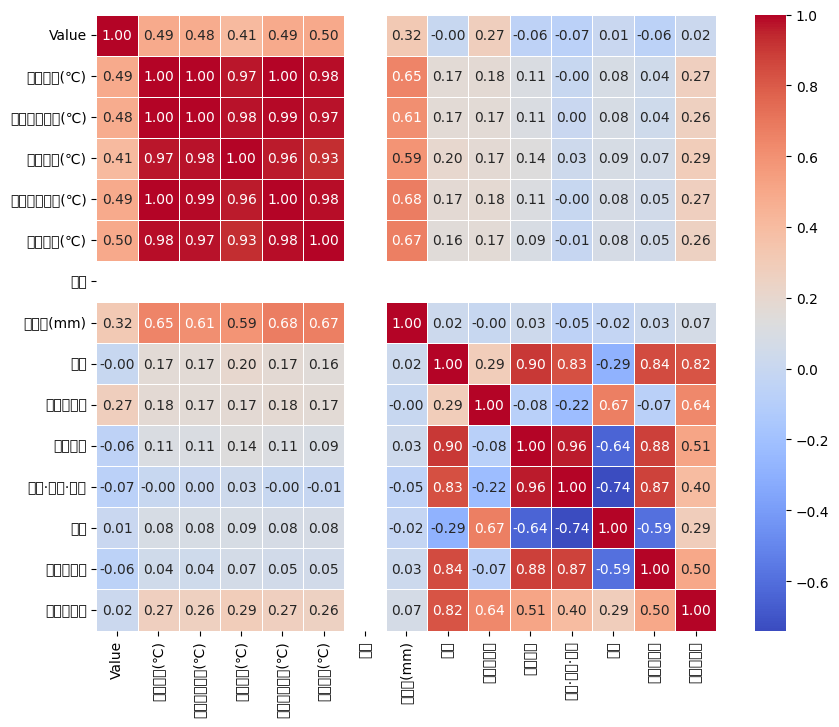

In [15]:
# 상관계수 히트맵 그리기
#sns.heatmap(corr_cabbage, annot=True, fmt='.2f')

import seaborn as sns
import matplotlib.pyplot as plt

# 숫자형 데이터만 선택
corr_cabbage = merge_final.select_dtypes(include='number').corr()

# 히트맵 그리기
plt.figure(figsize=(10, 8))  # 그래프 크기 조절
sns.heatmap(corr_cabbage, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

In [35]:
# 공분산
cov_cabbage = merge_final_numeric.cov()
cov_cabbage

,Value,평균기온(℃),평균최고기온(℃),최고기온(℃),평균최저기온(℃),최저기온(℃),강수량(mm),소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
Value,2.587259e+06,7779.453220,7511.922712,5496.315480,8084.197175,9574.427119,74732.584068,-9.702757,3285.747627,-412.894237,-2743.210249,20.682237,-268.418260,100.538294
평균기온(℃),7.779453e+03,99.247737,96.935873,81.187127,101.939746,117.399195,937.612263,5.229875,12.987788,4.742508,-0.124895,1.643029,1.166968,8.716425
평균최고기온(℃),7.511923e+03,96.935873,95.174178,80.020347,99.118559,114.122246,863.031585,5.029164,12.239449,4.585136,0.532681,1.607232,0.985002,8.380968
최고기온(℃),5.496315e+03,81.187127,80.020347,70.581726,82.682853,93.742415,719.971178,5.186651,10.705110,5.005525,6.180894,1.454422,1.468701,8.024255
평균최저기온(℃),8.084197e+03,101.939746,99.118559,82.682853,105.151921,121.189068,1010.586695,5.496573,13.608780,4.979203,-0.305588,1.667424,1.450859,9.118073
최저기온(℃),9.574427e+03,117.399195,114.122246,93.742415,121.189068,144.463263,1173.156059,5.796750,14.918619,4.866644,-3.516000,1.835924,1.638941,10.139059
강수량(mm),7.473258e+04,937.612263,863.031585,719.971178,1010.586695,1173.156059,21108.759263,10.656786,-1.554280,19.955847,-198.617037,-5.724249,10.536490,34.815998
소계,-9.702757e+00,5.229875,5.029164,5.186651,5.496573,5.796750,10.656786,9.609130,6.713470,12.222392,64.247489,-1.783204,6.890128,8.315665
농축수산물,3.285748e+03,12.987788,12.239449,10.705110,13.608780,14.918619,-1.554280,6.713470,55.459090,-2.716664,-41.652720,9.912073,-1.465453,15.529132
공업제품,-4.128942e+02,4.742508,4.585136,5.005525,4.979203,4.866644,19.955847,12.222392,-2.716664,19.004807,104.564459,-5.547434,10.112724,7.319253


In [36]:
from sklearn.decomposition import PCA

# 상관관계가 높은 평균기온, 평균 최저기온 컬럼 선택
selected_df = merge_final.loc[:, ['평균기온(℃)', '평균최저기온(℃)','최고기온(℃)','최저기온(℃)']]

# 주성분 분석을 통해 차원 축소
pca = PCA(n_components = 0.95)
selected_pca = pca.fit_transform(selected_df)
selected_pca.shape # 1차원인것 확인


(60, 1)

In [37]:
# 데이터프레임의 축소된 차원(공통요인) 추가
df_pca = pd.DataFrame(selected_pca, columns = ['기온'])
result_df = pd.concat([merge_final,df_pca], axis = 1)
result_df.head()

,구분,Year,Value,date,지점명,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),...,지점,강수량(mm),소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스,기온
48,01월,2020년,4608,2020-01-01,서울,1.6,5.9,11.9,2020-01-26,-1.7,...,108,60.5,106.09,115.77,102.89,88.98,106.32,102.20,111.26,-30.096014
49,02월,2020년,4366,2020-02-01,서울,2.5,7.2,15.6,2020-02-15,-1.3,...,108,53.1,106.06,114.81,103.09,88.98,106.40,102.05,111.21,-16.436269
50,03월,2020년,4343,2020-03-01,서울,7.7,13.3,20.6,2020-03-26,2.6,...,108,16.3,105.97,115.96,102.59,88.98,106.50,101.85,111.18,-14.644490
51,04월,2020년,4508,2020-04-01,서울,11.1,16.6,23.8,2020-04-16,6.3,...,108,16.9,105.55,116.78,101.54,88.98,106.58,100.70,111.20,4.891638
52,05월,2020년,4793,2020-05-01,서울,18.0,23.3,30.0,2020-05-30,13.7,...,108,112.4,105.32,114.88,101.41,88.98,106.74,100.57,110.92,7.591085


In [ ]:
# # 필요없는 컬럼 지웠어야함
#가격과 기온/강수량/물가지수간의 상관관계 분석
# 모두 높지 않은 형태를 띄고 있음

# 강사님 풀이
# 이동한다는 것(shift) -> 당장의 날씨보다 전의 날씨가 가격에 영향을 더 미칠 수 있겠다
# (이때 shift의 값을 1, 2, 3으로 바꾸며 1개월 2개월 3개월 간의 상관관계를 볼 수 있다.
# 비교하면서 1이 제일 상관관계가 높다는 것 파악 가능)

# 그렇게 되면 처음 값이 비어있게됨(하나씩 밀어줬기 때문에)
# 12개월 뒤에 있는 데이터를 다시 가져와서 채워줌(연단위) (-13)

# 그렇게 df_move의 corr()을 보면
# 상관계수가 더 temp,rain그대로 놓는 것보다 이동시켜서 상관계수를 보았을 때 강수량이 더 영향을 미쳐보인다

In [ ]:
# 고유값 고유벡터

# 어떤 데이터가 막 산포되어있다
# 그 때 데이터를 한 선으로 옮긴다.
# 그 하나의 축으로 옮기려면 내적을 통해 그 선이 되어줘야한다.(그 값이 고유벡터)
# 고유 값 (람다)란?
# 벡터에 올라온 값들이 일렬로 늘어놓기 위해 크기를 준?

# 그래서 그것들에 대해 옮겨지는 정도를 최소화를 시켜주는

In [ ]:
# 정규화 (강사님 풀이과정 중)
# describe()를 했을 때
# 두개의 데이터의 값이 차이가 많이 나면 (mean 값의 차이가 많이 나면) 정규화 진행
'''
  # 기온과 강수량 데이터 정류화
  데이터 단위가 다르면 정규화 해주는 것도 방법이다!
  from scipy import stats
  selected_zscore = stats_zscore(selected)
  selected_zscore

  # 정규화 데이터 기반으로 pca 분석
  # 두개의 차원으로 변경됨
  # 차원이 두개로 변경되었다는건 두개에서 두개이니 필요는 없지만
  # 이런식으로 정규화 할 수 있다는 것을 알아두기
'''

In [ ]:
'''
 오늘 총정리

 변수선택 : 변수를 제거하거나 기존 변수를 통합/축소하여 새로운 변수를 만드는 방법

 차원이 고차원일경우 해석이 어려움/ 차원 높은 것이 좋은 성능을 보장하지 않는다
 그렇기 때문에 차원을 축소(변수선택)해볼 수 있다.

 차원을 축소
 - aggregation (요약된 변수)
   ex) 기온 (평균, 최고, 최저, 평균최고, 평균최저) 다 사용하지 않고 평균 값만 사용
 - 파생변수(주관적 의미가 들어감, 기존 변수가지고 새로운 변수를 만드는 것)

 변수간 상관관계 있을 때 분석결과에 상관도가 높은 변수를 사용하면
 분석결과에 다중공선성(동일 변수 중복반영) 이라는 오류 발생
 이들을 축소해줘야함 : 1) 종속변수랑 상관도 높은 변수 추가
                     낮은 변수 제거

                  2)요인 분석  /공통요인 찾아 새로운 분석 추가
                    우리는 그 중 주성분 분석을 사용함
'''
'''
  주성분 분석이라는 것은 k개의 차원으로 선형 변환을 해주는 것 (위에 실습은 1개의 차원으로 해줌)
  여기서 적절한 차원 수라고 하는 것은
  주성분 : 데이터의 분산이 가장 큰 축
         분산 반영 비율을 보는데 약 95% 반영되면 적절한 차원이라고 생각함.

- 강사님

In [ ]:
df_price = pd.read_csv('/content/df_price.csv')
df_price.head()

,구분,Year,Value,date
0,01월,2024년,3043,2024-01-01
1,02월,2024년,3457,2024-02-01
2,03월,2024년,3673,2024-03-01
3,04월,2024년,4402,2024-04-01
4,05월,2024년,3814,2024-05-01


In [ ]:
df_degree = pd.read_csv('/content/df_degree.csv')
df_degree.head()

,\t\t지점번호,지점명,일시,평균기온(℃),평균최고기온(℃),최고기온(℃),\t최고기온일자,평균최저기온(℃),최저기온(℃),최저기온일자
0,108,서울,2020-01-01,1.6,5.9,11.9,2020-01-26,-1.7,-6.5,2020-01-01
1,108,서울,2020-02-01,2.5,7.2,15.6,2020-02-15,-1.3,-11.8,2020-02-06
2,108,서울,2020-03-01,7.7,13.3,20.6,2020-03-26,2.6,-2.8,2020-03-05
3,108,서울,2020-04-01,11.1,16.6,23.8,2020-04-16,6.3,1.9,2020-04-05
4,108,서울,2020-05-01,18.0,23.3,30.0,2020-05-30,13.7,9.2,2020-05-20


In [ ]:
df_rain = pd.read_csv('/content/df_rain.csv')
df_rain.head()

,년월,지점,강수량(mm)
0,2020-01-01,108,60.5
1,2020-02-01,108,53.1
2,2020-03-01,108,16.3
3,2020-04-01,108,16.9
4,2020-05-01,108,112.4


In [ ]:
df_index = pd.read_csv('/content/df_index.csv')
df_index.head()

,시점,소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
0,2020-01-01,106.09,115.77,102.89,88.98,106.32,102.20,111.26
1,2020-02-01,106.06,114.81,103.09,88.98,106.40,102.05,111.21
2,2020-03-01,105.97,115.96,102.59,88.98,106.50,101.85,111.18
3,2020-04-01,105.55,116.78,101.54,88.98,106.58,100.70,111.20
4,2020-05-01,105.32,114.88,101.41,88.98,106.74,100.57,110.92


In [ ]:
# 데이터프레임 병합
df = pd.merge(df_price, df_degree, left_on='date', right_on='일시')
df = pd.merge(df, df_rain, left_on='date', right_on='년월')
df = pd.merge(df, df_index, left_on='date', right_on='시점')
df.head()

,구분,Year,Value,date,\t\t지점번호,지점명,일시,평균기온(℃),평균최고기온(℃),최고기온(℃),...,지점,강수량(mm),시점,소계,농축수산물,공업제품,전기·수도·가스,집세,공공서비스,개인서비스
0,01월,2024년,3043,2024-01-01,108,서울,2024-01-01,-0.5,3.6,10.6,...,108,18.9,2024-01-01,112.60,123.65,112.23,140.71,103.96,106.17,115.01
1,02월,2024년,3457,2024-02-01,108,서울,2024-02-01,3.8,8.2,18.3,...,108,74.7,2024-02-01,113.07,126.82,112.64,140.71,104.05,106.06,115.46
2,03월,2024년,3673,2024-03-01,108,서울,2024-03-01,7.0,12.0,23.4,...,108,29.9,2024-03-01,113.02,127.28,112.76,140.71,104.13,105.97,115.12
3,04월,2024년,4402,2024-04-01,108,서울,2024-04-01,16.3,22.4,29.4,...,108,33.2,2024-04-01,113.37,125.62,112.94,140.71,104.18,106.04,116.32
4,05월,2024년,3814,2024-05-01,108,서울,2024-05-01,18.5,23.7,28.5,...,108,125.1,2024-05-01,113.42,123.55,113.17,140.71,104.28,106.02,116.63


In [ ]:
# 필요한 컬럼만 선택
df = df.loc[:, ['date', 'Value', '평균기온(℃)', '강수량(mm)', '소계', '농축수산물']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     60 non-null     object 
 1   Value    60 non-null     int64  
 2   평균기온(℃)  60 non-null     float64
 3   강수량(mm)  60 non-null     float64
 4   소계       60 non-null     float64
 5   농축수산물    60 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.9+ KB


In [ ]:
# 컬럼명 변경
df.rename(columns={"Value": "price",
                   "평균기온(℃)": "temperature",
                   "강수량(mm)": "rain",
                   "소계": "index_total",
                   "농축수산물": "index_agr"}, inplace=True)

In [ ]:
corr_price = df.iloc[:,1:].corr()
corr_price

,price,temperature,rain,index_total,index_agr
price,1.000000,0.485477,0.319785,-0.001946,0.274301
temperature,0.485477,1.000000,0.647786,0.169351,0.175061
rain,0.319785,0.647786,1.000000,0.023662,-0.001437
index_total,-0.001946,0.169351,0.023662,1.000000,0.290816
index_agr,0.274301,0.175061,-0.001437,0.290816,1.000000


<Axes: >

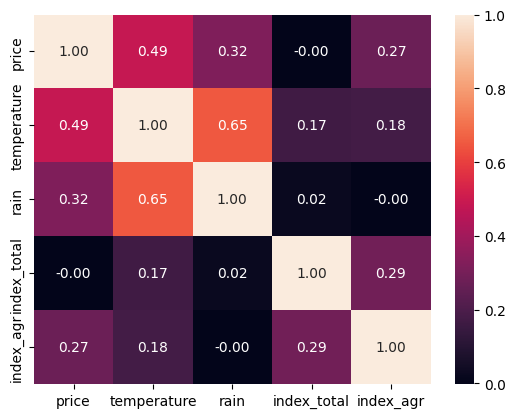

In [ ]:
sns.heatmap(corr_price, annot=True, fmt='.2f')

- 상관관계 분석 결과
    - 가격은 기온, 강수량, 물가지수와 약한 상관관계를 가지고 있다. → 우리가 생각한 가격에 영향을 주는 요인들에 대한 가정이 틀린 것일 수 있다.
        - 새로운 가설을 세우고 이에 대한 데이터 수집, 기존 데이터 변환을 고려
            - 기온과 강수량은 가격에 바로 영향을 미치지 않으므로 데이터를 이동하여 분석
    - 기온과 강수량은 0.65의 상관계수로 강한 상관관계를 가지고 있다.
        - 두개의 변수에 대하여 어떻게 할지 검토한다.
            - 가격과 연관도가 더 높은 기온만 선택
            - 기온과 강수량을 대변할 수 있는 변수를 생성
        - 0.7이하이므로 그대로 분석한다.

In [ ]:
# 기온과 강수량 데이터를 1개월 이전값으로 사용
# 날짜를 기준으로 정렬
df = df.sort_values(by='date', ascending=True, ignore_index=True)
df.tail()

# 기온과 강수량데이터 1개월 이동
df_move = df.copy()
df_move['temperature+m'] = df_move['temperature'].shift(1)
df_move['rain+m'] = df_move['rain'].shift(1)
# df_move.head()

# 결측치에 대해 1년전의 값으로 대체
df_move["temperature+m"] = df_move["temperature+m"].fillna(df_move["temperature+m"].shift(-13))
df_move["rain+m"] = df_move["rain+m"].fillna(df_move["rain+m"].shift(-13))
df_move.head(13)

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9
5,2020-06-01,4372,23.9,139.6,105.51,115.69,18.0,112.4
6,2020-07-01,4885,24.1,270.4,105.42,116.26,23.9,139.6
7,2020-08-01,7422,26.5,675.7,106.05,122.81,24.1,270.4
8,2020-09-01,10740,21.4,181.5,106.51,131.82,26.5,675.7
9,2020-10-01,7242,14.3,0.0,105.96,130.67,21.4,181.5


In [ ]:
df_move.iloc[:, 1:].corr()

,price,temperature,rain,index_total,index_agr,temperature+m,rain+m
price,1.000000,0.485477,0.319785,-0.001946,0.274301,0.580771,0.693091
temperature,0.485477,1.000000,0.647786,0.169351,0.175061,0.843583,0.561425
rain,0.319785,0.647786,1.000000,0.023662,-0.001437,0.561506,0.364127
index_total,-0.001946,0.169351,0.023662,1.000000,0.290816,0.242994,0.095236
index_agr,0.274301,0.175061,-0.001437,0.290816,1.000000,0.259949,0.220764
temperature+m,0.580771,0.843583,0.561506,0.242994,0.259949,1.000000,0.645429
rain+m,0.693091,0.561425,0.364127,0.095236,0.220764,0.645429,1.000000


- 1개월씩 데이터를 이동시켰을 때 상관관계가 더 높게 측정됨

In [ ]:
# 기온과 강수량을 대변할 수 있는 새로운 차원 생성
seleceted = df_move.loc[:, ['temperature', 'rain']]
pca = PCA(n_components=0.95)
selected_pca = pca.fit_transform(seleceted)
selected_pca.shape #한개의 차원으로 변경됨

(60, 1)

In [ ]:
# 변경된 차원과 기존 데이터프레임 병합
pca_df = pd.DataFrame(selected_pca, columns=['temp*rain'])
result_df = pd.concat([df_move, pca_df], axis=1)
result_df.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927


In [ ]:
# 이동된 기온과 강수량을 대변할 수 있는 새로운 차원 생성
seleceted = df_move.loc[:, ['temperature+m', 'rain+m']]
pca = PCA(n_components=0.95)
selected_pca = pca.fit_transform(seleceted)
print(selected_pca.shape) #한개의 차원으로 변경됨

# 변경된 차원과 기존 데이터프레임 병합
pca_df = pd.DataFrame(selected_pca, columns=['temp*rain+1'])
result_df = pd.concat([result_df, pca_df], axis=1)
result_df.head()

(60, 1)


,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229


In [ ]:
seleceted.describe()

,temperature+m,rain+m
count,60.000000,60.000000
mean,13.761667,125.605000
std,10.041424,145.114125
min,-2.800000,0.000000
25%,6.050000,20.025000
50%,14.700000,85.200000
75%,23.325000,146.825000
max,29.300000,675.700000


In [ ]:
# 기온과 강수량 데이터 정규화
from scipy import stats
seleceted_zscores = stats.zscore(seleceted)
seleceted_zscores

# 정규화 데이터 기반 PCA분석
pca = PCA(n_components=1) #한개의 차원으로 변환
selected_z_pca = pca.fit_transform(seleceted_zscores)
print(pca.explained_variance_ratio_) # 0.82로 80%이므로 이를 활용
selected_z_pca.shape

[0.82271428]


(60, 1)

In [ ]:
# 정규화된 기온과 강수량에 대한 새로운 데이터 프레임 병합
pca_z_df = pd.DataFrame(selected_z_pca, columns=['temp*rain_Z'])
result_df = pd.concat([result_df, pca_z_df], axis=1)
result_df.head()

,date,price,temperature,rain,index_total,index_agr,temperature+m,rain+m,temp*rain,temp*rain+1,temp*rain_Z
0,2020-01-01,4608,1.6,60.5,106.09,115.77,-2.4,18.9,-65.364248,-107.321243,-1.672028
1,2020-02-01,4366,2.5,53.1,106.06,114.81,1.6,60.5,-72.716873,-65.583936,-1.183558
2,2020-03-01,4343,7.7,16.3,105.97,115.96,2.5,53.1,-109.249050,-72.936258,-1.156009
3,2020-04-01,4508,11.1,16.9,105.55,116.78,7.7,16.3,-108.498360,-109.466750,-0.967571
4,2020-05-01,4793,18.0,112.4,105.32,114.88,11.1,16.9,-12.785927,-108.715229,-0.723177


In [ ]:
# 병합된 데이터 프레임 저장
result_df.to_csv('df_price_merge.csv', index=False)